# RPS PreTrained YOLO Fine-tuning

## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## 경로 설정

In [ ]:
if colab:
    # 코랩(Colab) 환경일 때의 경로 (은수님의 실제 구글 드라이브 폴더명 반영)
    save_dir = '/content/drive/MyDrive/AI_COLAB_examples/save/'
    dataset_zip = '/content/drive/MyDrive/AI_COLAB_examples/Traffic_Dataset.zip'
    dataset_root = '/content/Traffic_Dataset'
    project_root = '/content/drive/MyDrive/AI_COLAB_examples/runs'
else:
    # 로컬(PC) 환경일 때의 경로
    save_dir = '../save/'
    dataset_zip = '../Traffic_Dataset.zip'
    dataset_root = './Traffic_Dataset'
    project_root = './runs'

## RPS 데이터셋 준비

In [ ]:
!unzip -q -o {dataset_zip} -d {dataset_root}

## RPS 데이터셋의 Label 만들기

In [ ]:
import json
import os
import random
import shutil

CLASSES = [
    'traffic_light_red',
    # 'traffic_light_yellow',
    'traffic_light_green'
]

def get_light_color(obj):
    """신호등 객체의 attribute에서 켜진(on) 색상을 우선순위에 따라 하나만 반환."""
    attrs = obj.get('attribute', [])
    if not attrs:
        return None
    a = attrs[0]

    if a.get('red') == 'on':
        return 'traffic_light_red'
    # if a.get('yellow') == 'on':
    #     return 'traffic_light_yellow'
    if a.get('green') == 'on':
        return 'traffic_light_green'
    return None

def get_class_key(obj):
    """JSON 객체에서 최종 클래스 키를 결정합니다."""
    cls = obj.get('class')
    if cls == 'traffic_light':
        return get_light_color(obj)
    return None

def convert(size, box):
    dw = 1. / size[0]; dh = 1. / size[1]
    x = (box[0] + box[2]) / 2.0; y = (box[1] + box[3]) / 2.0
    w = box[2] - box[0]; h = box[3] - box[1]
    return (x * dw, y * dh, w * dw, h * dh)

train_img_dir = os.path.join(dataset_root, 'images/train')
train_label_dir = os.path.join(dataset_root, 'labels/train')
os.makedirs(train_label_dir, exist_ok=True)

class_counts = {c: 0 for c in CLASSES}

json_files = [f for f in os.listdir(train_img_dir) if f.endswith('.json') or f.endswith('.JSON')]
for filename in json_files:
    in_file = os.path.join(train_img_dir, filename)
    out_file = os.path.join(train_label_dir, filename.rsplit('.', 1)[0] + '.txt')

    with open(in_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    try:
        w = float(data['image']['imsize'][0])
        h = float(data['image']['imsize'][1])
        objects = data.get('annotation', [])
    except KeyError:
        continue

    with open(out_file, 'w') as out_f:
        for obj in objects:
            cls_key = get_class_key(obj)
            if cls_key is None or cls_key not in CLASSES:
                continue
            if 'box' not in obj:
                continue
            cls_id = CLASSES.index(cls_key)
            bb = convert((w, h), obj['box'])
            out_f.write(f"{cls_id} " + " ".join([f"{a:.6f}" for a in bb]) + "\n")
            class_counts[cls_key] += 1

print(f"JSON -> TXT 변환 완료: 총 {len(json_files)}개 파일")
print("\n클래스별 객체 수:")
for c in CLASSES:
    print(f"  {c}: {class_counts[c]}")

JSON -> TXT 변환 완료: 총 3070개 파일

클래스별 객체 수:
  traffic_light_red: 309
  traffic_light_green: 569


In [ ]:
import os, random, shutil

train_img_dir = os.path.join(dataset_root, 'images/train')
train_label_dir = os.path.join(dataset_root, 'labels/train')
val_img_dir = os.path.join(dataset_root, 'images/val')
val_label_dir = os.path.join(dataset_root, 'labels/val')
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

all_images = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print("이미지 파일 개수(json 제외):", len(all_images))

val_size = int(len(all_images) * 0.2)
val_images = random.sample(all_images, val_size)

moved_img = 0
moved_label = 0
for img in val_images:
    shutil.move(os.path.join(train_img_dir, img), os.path.join(val_img_dir, img))
    moved_img += 1
    txt_file = img.rsplit('.', 1)[0] + '.txt'
    src_label = os.path.join(train_label_dir, txt_file)
    if os.path.exists(src_label):
        shutil.move(src_label, os.path.join(val_label_dir, txt_file))
        moved_label += 1

print(f"이미지 이동: {moved_img}개, 라벨 이동: {moved_label}개")
print("val 폴더 최종 이미지 수:", len(os.listdir(val_img_dir)))

이미지 파일 개수(json 제외): 3070
이미지 이동: 614개, 라벨 이동: 614개
val 폴더 최종 이미지 수: 614


In [ ]:
import os
import shutil
import random

def rebuild_dataset(img_dir, label_dir, out_img_dir, out_label_dir, empty_ratio=0.25, seed=42):
    random.seed(seed)
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)

    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    labeled_files = []
    empty_files = []

    for fname in img_files:
        txt_path = os.path.join(label_dir, fname.replace('.jpg', '.txt'))
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            labeled_files.append(fname)
        else:
            empty_files.append(fname)

    n_empty_keep = int(len(labeled_files) * empty_ratio)
    n_empty_keep = min(n_empty_keep, len(empty_files))
    sampled_empty = random.sample(empty_files, n_empty_keep)

    kept_files = labeled_files + sampled_empty

    for fname in kept_files:
        shutil.copy(os.path.join(img_dir, fname), os.path.join(out_img_dir, fname))
        txt_path = os.path.join(label_dir, fname.replace('.jpg', '.txt'))
        if os.path.exists(txt_path):
            shutil.copy(txt_path, os.path.join(out_label_dir, fname.replace('.jpg', '.txt')))
        else:
            open(os.path.join(out_label_dir, fname.replace('.jpg', '.txt')), 'w').close()

    return len(labeled_files), len(sampled_empty)

new_root = '/content/Traffic_Light_Balanced_v8'

l, e = rebuild_dataset(
    os.path.join(dataset_root, 'images/train'),
    os.path.join(dataset_root, 'labels/train'),
    os.path.join(new_root, 'images/train'),
    os.path.join(new_root, 'labels/train'),
    empty_ratio=0.0
)
print(f"train: 라벨 있음 {l}장 + 빈 사진 {e}장 = 총 {l+e}장")

l, e = rebuild_dataset(
    os.path.join(dataset_root, 'images/val'),
    os.path.join(dataset_root, 'labels/val'),
    os.path.join(new_root, 'images/val'),
    os.path.join(new_root, 'labels/val'),
    empty_ratio=0.0
)
print(f"val: 라벨 있음 {l}장 + 빈 사진 {e}장 = 총 {l+e}장")

train: 라벨 있음 399장 + 빈 사진 0장 = 총 399장
val: 라벨 있음 114장 + 빈 사진 0장 = 총 114장


In [ ]:
# import os, glob, random, shutil

# random.seed(42)

# label_files = glob.glob(os.path.join(train_label_dir, '*.txt'))

# per_image = {}
# for lf in label_files:
#     red_cnt = green_cnt = 0
#     with open(lf) as f:
#         for line in f:
#             line = line.strip()
#             if not line:
#                 continue
#             cls_id = int(line.split()[0])
#             if cls_id == 0:
#                 red_cnt += 1
#             elif cls_id == 1:
#                 green_cnt += 1
#     per_image[lf] = (red_cnt, green_cnt)

# red_total = sum(v[0] for v in per_image.values())
# green_total = sum(v[1] for v in per_image.values())
# print(f"원본 - red: {red_total}, green: {green_total}")

# target_remove = green_total - red_total

# green_only = [lf for lf, (r, g) in per_image.items() if r == 0 and g > 0]
# random.shuffle(green_only)

# remove_set = set()
# removed_green = 0
# for lf in green_only:
#     r, g = per_image[lf]
#     if removed_green + g <= target_remove:
#         remove_set.add(lf)
#         removed_green += g
#     else:
#         need = target_remove - removed_green
#         if need > 0:
#             with open(lf) as f:
#                 lines = f.readlines()
#             green_idx = [i for i, l in enumerate(lines) if l.strip() and int(l.split()[0]) == 1]
#             drop = set(random.sample(green_idx, need))
#             with open(lf, 'w') as f:
#                 f.writelines(l for i, l in enumerate(lines) if i not in drop)
#             removed_green += need
#         break

# print(f"이미지 단위 제외/조정으로 줄어드는 green: {removed_green} (목표 {target_remove})")

# remainder = target_remove - removed_green
# if remainder > 0:
#     mixed = [lf for lf, (r, g) in per_image.items() if lf not in remove_set and g > 0]
#     random.shuffle(mixed)
#     for lf in mixed:
#         if remainder <= 0:
#             break
#         with open(lf) as f:
#             lines = f.readlines()
#         green_idx = [i for i, l in enumerate(lines) if l.strip() and int(l.split()[0]) == 1]
#         n_drop = min(len(green_idx), remainder)
#         drop = set(random.sample(green_idx, n_drop))
#         with open(lf, 'w') as f:
#             f.writelines(l for i, l in enumerate(lines) if i not in drop)
#         remainder -= n_drop

# print(f"보정 후 부족분: {remainder} (0이면 정확히 균형)")

# out_img_dir = os.path.join(new_root, 'images/train')
# out_label_dir = os.path.join(new_root, 'labels/train')
# os.makedirs(out_img_dir, exist_ok=True)
# os.makedirs(out_label_dir, exist_ok=True)

# kept = [lf for lf in label_files if lf not in remove_set]
# for lf in kept:
#     base = os.path.splitext(os.path.basename(lf))[0]
#     shutil.copy(lf, os.path.join(out_label_dir, base + '.txt'))
#     for ext in ('.jpg', '.jpeg', '.png'):
#         src_img = os.path.join(train_img_dir, base + ext)
#         if os.path.exists(src_img):
#             shutil.copy(src_img, os.path.join(out_img_dir, base + ext))
#             break

# final_red = sum(int(l.split()[0]) == 0 for lf in kept for l in open(lf) if l.strip())
# final_green = sum(int(l.split()[0]) == 1 for lf in kept for l in open(lf) if l.strip())
# print(f"최종 - red: {final_red}, green: {final_green}")

In [ ]:
import yaml

new_root = '/content/Traffic_Light_Balanced_v8'
data = {
    'train': f'{new_root}/images/train',
    'val': f'{new_root}/images/val',
    'nc': 2,
    'names': ['traffic_light_red', 'traffic_light_green']
}
yaml_path = os.path.join(new_root, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)
print("data.yaml 생성:", yaml_path)

data.yaml 생성: /content/Traffic_Light_Balanced_v8/data.yaml


## Ultralytics 설치 및 import

In [ ]:
!pip -q install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import json
import os

train_img_dir = os.path.join(dataset_root, 'images/train')
json_files = [f for f in os.listdir(train_img_dir) if f.endswith('.json')]

light_counts = {'red': 0, 'green': 0}

for filename in json_files:
    with open(os.path.join(train_img_dir, filename), 'r', encoding='utf-8') as f:
        data = json.load(f)
    for obj in data.get('annotation', []):
        if obj.get('class') != 'traffic_light':
            continue
        attrs = obj.get('attribute', [])
        if not attrs:
            continue
        a = attrs[0]
        if a.get('red') == 'on':
            light_counts['red'] += 1
        # elif a.get('yellow') == 'on':
        #     light_counts['yellow'] += 1
        elif a.get('green') == 'on':
            light_counts['green'] += 1

print("신호등 색상별 인스턴스 수:", light_counts)

신호등 색상별 인스턴스 수: {'red': 309, 'green': 569}


## 학습

In [ ]:
yolo = YOLO('yolo11n.pt')

In [ ]:
import os

val_label_dir = os.path.join(new_root, 'labels/val')
bad_boxes = []
all_boxes = []

for fname in os.listdir(val_label_dir):
    path = os.path.join(val_label_dir, fname)
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            cid, cx, cy, w, h = parts[0], *map(float, parts[1:])
            all_boxes.append((cid, cx, cy, w, h))
            if w <= 0.001 or h <= 0.001 or cx < 0 or cx > 1 or cy < 0 or cy > 1:
                bad_boxes.append((fname, cid, cx, cy, w, h))

print("전체 box 수:", len(all_boxes))
print("이상한 box 수:", len(bad_boxes))
print("이상 box 샘플:", bad_boxes[:10])

ws = [b[3] for b in all_boxes]
hs = [b[4] for b in all_boxes]
print(f"\nw 최소/최대/평균: {min(ws):.4f} / {max(ws):.4f} / {sum(ws)/len(ws):.4f}")
print(f"h 최소/최대/평균: {min(hs):.4f} / {max(hs):.4f} / {sum(hs)/len(hs):.4f}")

전체 box 수: 194
이상한 box 수: 0
이상 box 샘플: []

w 최소/최대/평균: 0.0047 / 0.0820 / 0.0216
h 최소/최대/평균: 0.0056 / 0.1458 / 0.0178


In [ ]:
DATA = f'{new_root}/data.yaml'

yolo = YOLO('yolo11n.pt')
yolo.train(data=DATA, epochs=80, batch=16,
            imgsz=640, device=0, workers=4,
            project=project_root,
            degrees=15.0, flipud=0.0, fliplr=0.5, mosaic=1.0,
            name='traffic_light_balanced_8')

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic_Light_Balanced_v8/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_light_balanced_8, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b6ac84f0c20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import os

train_img_dir = os.path.join(dataset_root, 'images/train')
val_img_dir = os.path.join(dataset_root, 'images/val')

print("train 폴더 파일 수:", len(os.listdir(train_img_dir)))
print("train 폴더 샘플 파일명 5개:", os.listdir(train_img_dir)[:5])
print("val 폴더 파일 수:", len(os.listdir(val_img_dir)))

train 폴더 파일 수: 5526
train 폴더 샘플 파일명 5개: ['s01001416.json', 's01001334.json', 's01000413.jpg', 's01000420.json', 's01002635.json']
val 폴더 파일 수: 614


In [ ]:
import os

print("project_root 경로:", project_root)
print("존재 여부:", os.path.exists(project_root))

if os.path.exists(project_root):
    print("\n하위 폴더 목록:")
    for item in os.listdir(project_root):
        print(" -", item)

print("\nbest.pt 검색 결과:")
for root, dirs, files in os.walk(project_root):
    for file in files:
        if file == 'best.pt':
            print(" 찾음:", os.path.join(root, file))

project_root 경로: /content/drive/MyDrive/AI_COLAB_examples/runs
존재 여부: True

하위 폴더 목록:
 - traffic_light_balanced_v1
 - traffic_light_balanced_v2
 - traffic_light_balanced_v3
 - traffic_light_balanced_v4
 - traffic_light_balanced_v5
 - traffic_light_balanced_v6
 - traffic_light_balanced_v7
 - compare_mAP50_curves.png
 - compare_final_bar.png
 - training_summary.png
 - traffic_light_balanced_8

best.pt 검색 결과:
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v1/weights/best.pt
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v2/weights/best.pt
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v3/weights/best.pt
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v4/weights/best.pt
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v5/weights/best.pt
 찾음: /content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_v6/weights/best.pt
 찾음: /content/drive/MyDrive/AI_C

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


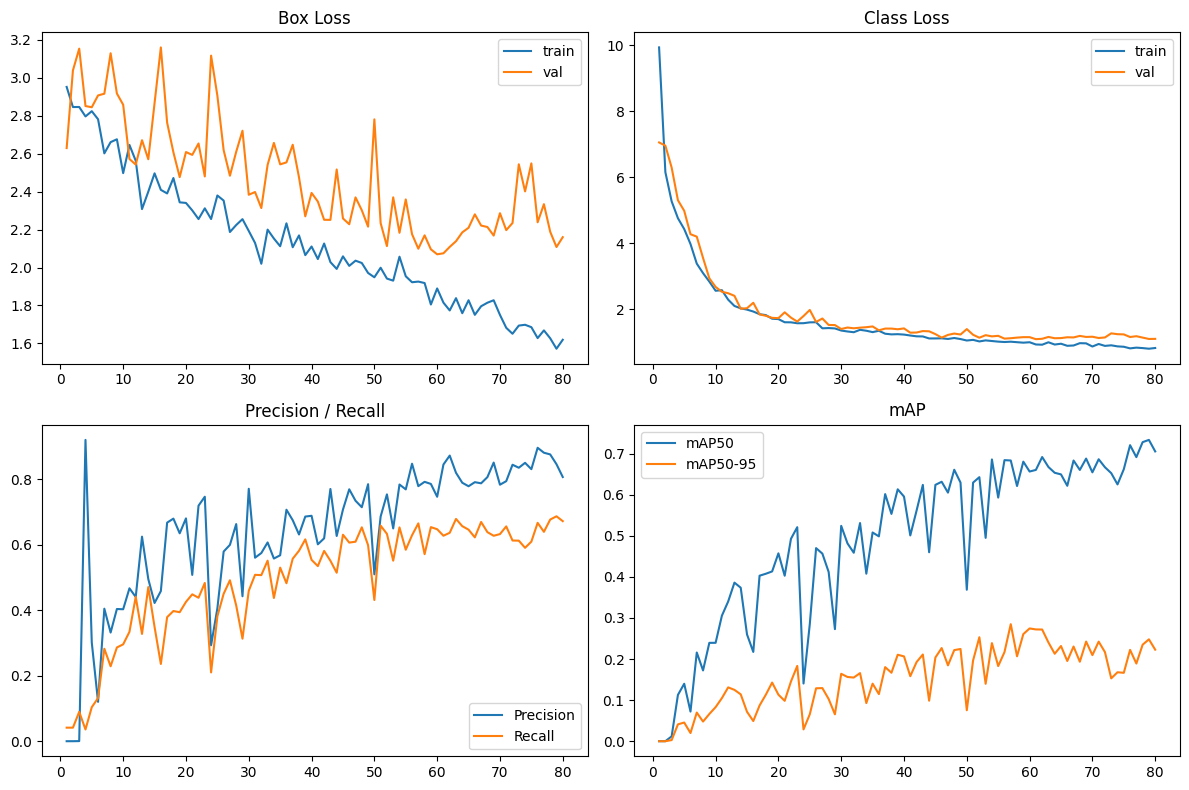

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = os.path.join(project_root, 'traffic_light_balanced_8', 'results.csv')
df = pd.read_csv(results_path)
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='train')
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='val')
axes[0, 0].set_title('Box Loss'); axes[0, 0].legend()

axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='train')
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='val')
axes[0, 1].set_title('Class Loss'); axes[0, 1].legend()

axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1, 0].set_title('Precision / Recall'); axes[1, 0].legend()

axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1, 1].set_title('mAP'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'training_summary.png'))
plt.show()

## ONNX 모델로 변환

In [ ]:
BEST = f'{project_root}/traffic_light_balanced_8/weights/best.pt'

# model obejct instantiation w/ best.pt
yolo_best = YOLO(BEST)
# model export to onnx format
yolo_best.export(format='onnx',
                 imgsz=640,
                 #int8=True,
                 opset=18,
                 simplify=True)


Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 485ms
Prepared 4 packages in 3.88s
Installed 4 packages in 247ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 5.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export wi

'/content/drive/MyDrive/AI_COLAB_examples/runs/traffic_light_balanced_8/weights/best.onnx'

## ONNX 파일 저장

In [ ]:
onnx_best = 'traffic_light_balanced_8.onnx'
save_file = f'{save_dir}/{onnx_best}'

In [ ]:
!cp {project_root}/traffic_light_balanced_8/weights/best.onnx {onnx_best}

In [ ]:
import os
# 저장할 디렉토리가 없는 경우를 대비해 생성합니다.
os.makedirs(os.path.dirname(save_file), exist_ok=True)

!cp {onnx_best} {save_file}
print(f"파일이 성공적으로 복사되었습니다: {save_file}")

파일이 성공적으로 복사되었습니다: /content/drive/MyDrive/AI_COLAB_examples/save//traffic_light_balanced_8.onnx


In [ ]:
from google.colab import files
files.download(onnx_best)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##COCO

In [ ]:
# from ultralytics import YOLO
# import os
# from google.colab import files

# coco_model = YOLO('yolo11n.pt')

# coco_model.export(format='onnx',
#                    imgsz=320,
#                    opset=18,
#                    simplify=True)

# onnx_coco = 'rps_yolo11n_coco.onnx'
# os.rename('yolo11n.onnx', onnx_coco)

# save_file = f'{save_dir}/{onnx_coco}'
# os.makedirs(os.path.dirname(save_file), exist_ok=True)
# import shutil
# shutil.copy(onnx_coco, save_file)

# files.download(onnx_coco)